In [24]:
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Supaya tampilan tabel di jupyter lebih lebar
pd.set_option('display.max_colwidth', None)

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


In [25]:
# Ganti nama file jika berbeda
file_path = 'Intrinsic-evaluation.xlsx'

# Membaca Excel
df = pd.read_excel(file_path)

# Membersihkan data: Mengisi sel kosong dengan teks kosong agar tidak error
df['Jawaban Chatbot'] = df['Jawaban Chatbot'].fillna("")
df['Kalimat Referensi'] = df['Kalimat Referensi'].fillna("")

print(f"✅ Data berhasil dimuat.")
print(f"📊 Total baris data: {len(df)}")
print("\nContoh 3 baris pertama:")
display(df.head(3))

✅ Data berhasil dimuat.
📊 Total baris data: 20

Contoh 3 baris pertama:


,No,Pertanyaan User,Jawaban Chatbot,Kalimat Referensi
0,1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang"
1,2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.
2,3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS


In [26]:
print("📊 Sedang menyusun Tabel Detail Lengkap (Prediksi, Referensi, & Breakdown Score)...")

# --- BAGIAN 1: Hitung Ulang Breakdown ROUGE (Supaya Data Pasti Benar) ---
# Kita hitung lagi sebentar untuk memastikan Precision/Recall/F1 terpisah dengan benar
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# List penampung sementara
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rl_p, rl_r, rl_f = [], [], []

for index, row in df.iterrows():
    cand = str(row['Jawaban Chatbot'])
    ref = str(row['Kalimat Referensi'])
    
    scores = scorer.score(ref, cand)
    
    # ROUGE-1
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    
    # ROUGE-2
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    
    # ROUGE-L (LCS)
    rl_p.append(scores['rougeL'].precision)
    rl_r.append(scores['rougeL'].recall)
    rl_f.append(scores['rougeL'].fmeasure)

# Masukkan ke DataFrame
df['R1_Precision'] = r1_p
df['R1_Recall'] = r1_r
df['R1_F1'] = r1_f

df['R2_Precision'] = r2_p
df['R2_Recall'] = r2_r
df['R2_F1'] = r2_f

df['RL_Precision'] = rl_p
df['RL_Recall'] = rl_r
df['RL_F1'] = rl_f

# --- BAGIAN 2: Menyusun Urutan Kolom (Format Laporan Skripsi) ---

# Definisikan urutan kolom yang diinginkan
target_order = [
    'Pertanyaan User',      # Kolom Teks
    'Jawaban Chatbot',      # Kalimat Prediksi
    'Kalimat Referensi',    # Kalimat Referensi
    
    # Detail ROUGE-1
    'R1_Precision', 'R1_Recall', 'R1_F1',
    
    # Detail ROUGE-2
    'R2_Precision', 'R2_Recall', 'R2_F1',
    
    # Detail ROUGE-LCS
    'RL_Precision', 'RL_Recall', 'RL_F1',
]

# Filter kolom (hanya ambil yang ada di df untuk menghindari error)
available_cols = [c for c in target_order if c in df.columns]
final_df = df[available_cols].copy()

# Rename kolom agar lebih jelas/Bahasa Indonesia (Opsional)
final_df = final_df.rename(columns={
    'Jawaban Chatbot': 'Kalimat Prediksi (Chatbot)',
    'R1_F1': 'R1_F-Measure',
    'R2_F1': 'R2_F-Measure',
    'RL_F1': 'RL_F-Measure'
})

# Tambahkan Nomor Urut di paling kiri
final_df.insert(0, 'No', range(1, len(final_df) + 1))

# --- BAGIAN 3: Formatting & Export ---

# Bulatkan semua kolom angka menjadi 4 desimal
numeric_cols = final_df.select_dtypes(include=['float64', 'float32']).columns
final_df[numeric_cols] = final_df[numeric_cols].round(4)

print(f"\n✅ Tabel berhasil disusun! Total Data: {len(final_df)} baris.")
print("Contoh 3 data pertama:")
display(final_df.head(3))


📊 Sedang menyusun Tabel Detail Lengkap (Prediksi, Referensi, & Breakdown Score)...

✅ Tabel berhasil disusun! Total Data: 20 baris.
Contoh 3 data pertama:


,No,Pertanyaan User,Kalimat Prediksi (Chatbot),Kalimat Referensi,R1_Precision,R1_Recall,R1_F-Measure,R2_Precision,R2_Recall,R2_F-Measure,RL_Precision,RL_Recall,RL_F-Measure
0,1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang",0.4667,0.4516,0.4590,0.2759,0.2667,0.2712,0.4000,0.3871,0.3934
1,2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.,0.7059,0.7059,0.7059,0.4375,0.4375,0.4375,0.6471,0.6471,0.6471
2,3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS,0.2000,1.0000,0.3333,0.1250,0.7500,0.2143,0.2000,1.0000,0.3333


In [27]:
print("🚀 Memulai perhitungan BERTScore Lengkap (P, R, F1)...")

# 1. Siapkan Data
cands = df['Jawaban Chatbot'].tolist()
refs = df['Kalimat Referensi'].tolist()

# Tempat menampung hasil sementara untuk ketiganya
all_precision = []
all_recall = []
all_f1 = []

# 2. Pengaturan Batch
batch_size = 5
total_data = len(df)

# 3. Mulai Proses dengan Loading Bar
with tqdm(total=total_data, desc="Progres") as pbar:
    
    for i in range(0, total_data, batch_size):
        start_idx = i
        end_idx = min(i + batch_size, total_data)
        
        # Log Manual
        print(f"🔄 Sedang memproses data ke-{start_idx + 1} sampai {end_idx}...")
        
        batch_cands = cands[start_idx : end_idx]
        batch_refs = refs[start_idx : end_idx]
        
        # Hitung BERTScore
        # P = Precision, R = Recall, F1 = F1 Score
        P, R, F1 = score(batch_cands, batch_refs, lang="id", verbose=False)
        
        # Simpan hasil batch ini ke list utama
        # Kita pakai .numpy() untuk mengubah format Tensor ke angka biasa
        all_precision.extend(P.numpy())
        all_recall.extend(R.numpy())
        all_f1.extend(F1.numpy())
        
        # Update loading bar
        pbar.update(len(batch_cands))

# 4. Masukkan ketiga hasil ke DataFrame (Kolom Baru)
df['BERT_Precision'] = all_precision
df['BERT_Recall'] = all_recall
df['BERT_F1'] = all_f1

print("\n✅ Perhitungan BERTScore SELESAI!")
print("Contoh hasil lengkap:")
display(df[['Jawaban Chatbot', 'BERT_Precision', 'BERT_Recall', 'BERT_F1']].head())

🚀 Memulai perhitungan BERTScore Lengkap (P, R, F1)...


🔄 Sedang memproses data ke-1 sampai 5...


🔄 Sedang memproses data ke-6 sampai 10...


🔄 Sedang memproses data ke-11 sampai 15...


🔄 Sedang memproses data ke-16 sampai 20...



Progres: 100%|██████████| 20/20 [00:07<00:00,  2.73it/s]


✅ Perhitungan BERTScore SELESAI!
Contoh hasil lengkap:


,Jawaban Chatbot,BERT_Precision,BERT_Recall,BERT_F1
0,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).",0.766607,0.749617,0.758017
1,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,0.875895,0.897442,0.886538
2,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,0.612942,0.636677,0.624584
3,"Mohon maaf, saya tidak menemukan informasi mengenai tempat mengunduh PKS magang mandiri di dalam konteks yang tersedia. Anda bisa tanyakan langsung hal ini ke Bu Intan.",0.657299,0.620298,0.638263
4,"Untuk durasi program magang selama 6 bulan, total konversi yang didapatkan setara dengan 20 SKS. Rincian: Magang Industri Digital (6 SKS), Softskill (2 SKS), Seminar (1 SKS), Matkul Pilihan (11 SKS).",0.681437,0.771301,0.723590


In [30]:
print("="*40)
print("HASIL EVALUASI INTRINSIK (RATA-RATA LENGKAP)")
print("="*40)

# --- ROUGE-1 ---
r1_p = df['R1_Precision'].mean()
r1_r = df['R1_Recall'].mean()
r1_f1 = df['R1_F1'].mean()

print(f"📌 ROUGE-1")
print(f"   Precision : {r1_p:.4f}")
print(f"   Recall    : {r1_r:.4f}")
print(f"   F1 Score  : {r1_f1:.4f}")

# --- ROUGE-2 ---
r2_p = df['R2_Precision'].mean()
r2_r = df['R2_Recall'].mean()
r2_f1 = df['R2_F1'].mean()

print(f"\n📌 ROUGE-2")
print(f"   Precision : {r2_p:.4f}")
print(f"   Recall    : {r2_r:.4f}")
print(f"   F1 Score  : {r2_f1:.4f}")

# --- ROUGE-L ---
rl_p = df['RL_Precision'].mean()
rl_r = df['RL_Recall'].mean()
rl_f1 = df['RL_F1'].mean()

print(f"\n📌 ROUGE-L (LCS)")
print(f"   Precision : {rl_p:.4f}")
print(f"   Recall    : {rl_r:.4f}")
print(f"   F1 Score  : {rl_f1:.4f}")

# --- BERTScore ---
# Pastikan cell BERTScore sudah dijalankan sebelumnya
if 'BERT_Precision' in df.columns:
    bert_p = df['BERT_Precision'].mean()
    bert_r = df['BERT_Recall'].mean()
    bert_f1 = df['BERT_F1'].mean()

    print(f"\n📌 BERTScore")
    print(f"   Precision : {bert_p:.4f}")
    print(f"   Recall    : {bert_r:.4f}")
    print(f"   F1 Score  : {bert_f1:.4f}")
else:
    print("\n⚠️ Kolom BERTScore belum ditemukan. Pastikan cell perhitungan BERT sudah dijalankan.")

print("="*40)

HASIL EVALUASI INTRINSIK (RATA-RATA LENGKAP)
📌 ROUGE-1
   Precision : 0.4916
   Recall    : 0.5664
   F1 Score  : 0.4827

📌 ROUGE-2
   Precision : 0.2846
   Recall    : 0.3552
   F1 Score  : 0.2888

📌 ROUGE-L (LCS)
   Precision : 0.4559
   Recall    : 0.5290
   F1 Score  : 0.4486

📌 BERTScore
   Precision : 0.7520
   Recall    : 0.7572
   F1 Score  : 0.7534


In [ ]:
import pandas as pd

print("📊 Sedang menyusun Tabel Konsolidasi Akhir...")

# 1. Memilih kolom yang benar (Sesuai nama kolom baru hasil breakdown tadi)
target_columns = [
    'Pertanyaan User', 
    'Jawaban Chatbot',
    'Kalimat Referensi',
    'R1_F1',        
    'R2_F1',        
    'RL_F1',        
    'BERT_Precision',
    'BERT_Recall',
    'BERT_F1'
]

# Cek agar tidak error (hanya ambil kolom yang benar-benar ada)
available_columns = [col for col in target_columns if col in df.columns]
final_df = df[available_columns].copy()

# 2. Rename kolom agar namanya kembali rapi untuk Laporan
final_df = final_df.rename(columns={
    'R1_F1': 'ROUGE-1',       # Kita ubah namanya di sini
    'R2_F1': 'ROUGE-2',
    'RL_F1': 'ROUGE-LCS',
    'BERT_Precision': 'BERT Precision',
    'BERT_Recall': 'BERT Recall',
    'BERT_F1': 'BERT F1 Score'
})

# 3. Tambahkan Nomor Urut
final_df.insert(0, 'No', range(1, len(final_df) + 1))

# 4. Format Angka: Membulatkan otomatis semua kolom angka yang ada
# Cara ini lebih aman daripada menulis nama kolom satu per satu
numeric_cols = final_df.select_dtypes(include=['number']).columns
# Kecuali kolom 'No', kita bulatkan sisanya
cols_to_round = [col for col in numeric_cols if col != 'No']
final_df[cols_to_round] = final_df[cols_to_round].round(4)

# 5. Tampilkan Tabel
print("\n=== TABEL KONSOLIDASI (DATA 1 - {}) ===".format(len(final_df)))
display(final_df.head()) # Tampilkan 5 baris awal saja

# 6. Simpan ke Excel Final
#output_final = 'Tabel_Konsolidasi_Evaluasi_Final.xlsx'
#final_df.to_excel(output_final, index=False)

#print(f"\n✅ Tabel konsolidasi berhasil disimpan ke: {output_final}")

📊 Sedang menyusun Tabel Konsolidasi Akhir...

=== TABEL KONSOLIDASI (DATA 1 - 20) ===


,No,Pertanyaan User,Jawaban Chatbot,Kalimat Referensi,ROUGE-1,ROUGE-2,ROUGE-LCS,BERT Precision,BERT Recall,BERT F1 Score
0,1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang",0.4590,0.2712,0.3934,0.7666,0.7496,0.7580
1,2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.,0.7059,0.4375,0.6471,0.8759,0.8974,0.8865
2,3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS,0.3333,0.2143,0.3333,0.6129,0.6367,0.6246
3,4,dimana saya bisa download PKS magang mandiri?,"Mohon maaf, saya tidak menemukan informasi mengenai tempat mengunduh PKS magang mandiri di dalam konteks yang tersedia. Anda bisa tanyakan langsung hal ini ke Bu Intan.",Untuk magang mandiri disertakan PKS magang untuk perusahaan yang dapat diakses pada : https://bit.ly/DataProdiBisdi,0.1905,0.1000,0.1429,0.6573,0.6203,0.6383
4,5,berapa total konversi SKS yang jika saya magang selama 6 bulan?,"Untuk durasi program magang selama 6 bulan, total konversi yang didapatkan setara dengan 20 SKS. Rincian: Magang Industri Digital (6 SKS), Softskill (2 SKS), Seminar (1 SKS), Matkul Pilihan (11 SKS).",TOTAL 20 sks — Durasi program selama 6 bulan setara dengan 20 SKS.,0.5116,0.2927,0.4186,0.6814,0.7713,0.7236


📊 Sedang men-generate grafik rata-rata...


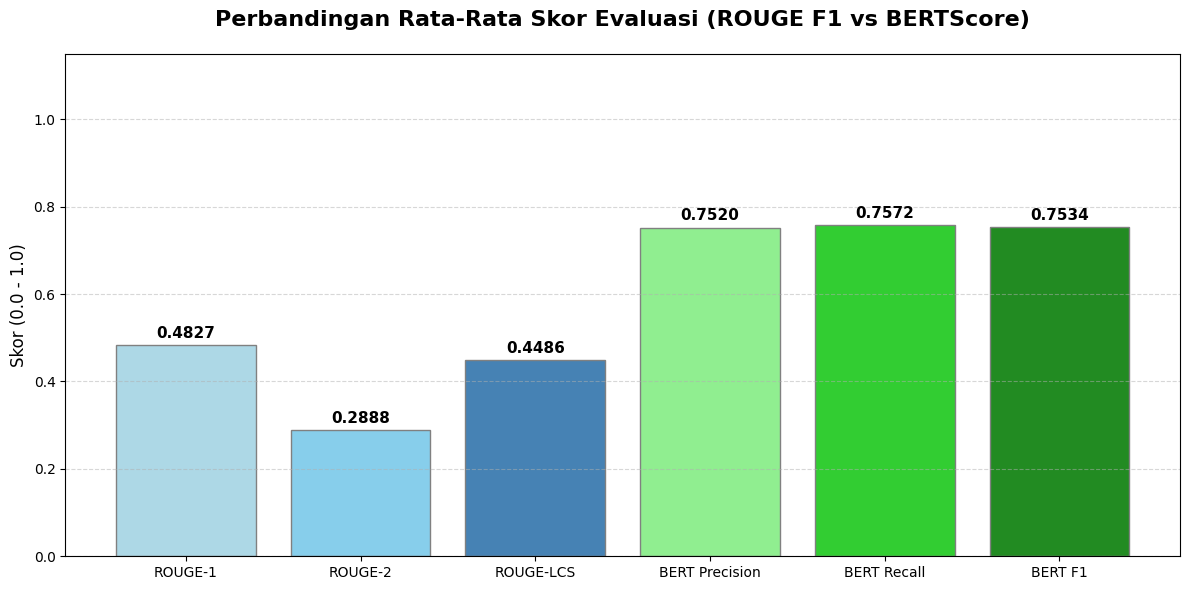

In [34]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Sedang men-generate grafik rata-rata...")

# 1. Siapkan Data Rata-Rata
# KITA UBAH BAGIAN INI: Menggunakan nama kolom baru (R1_F1, dst)
metrics_data = {
    'ROUGE-1': df['R1_F1'].mean(),      # <-- Ganti df['ROUGE-1'] jadi df['R1_F1']
    'ROUGE-2': df['R2_F1'].mean(),      # <-- Ganti df['ROUGE-2'] jadi df['R2_F1']
    'ROUGE-LCS': df['RL_F1'].mean(),    # <-- Ganti df['ROUGE-L'] jadi df['RL_F1']
    'BERT Precision': df['BERT_Precision'].mean(),
    'BERT Recall': df['BERT_Recall'].mean(),
    'BERT F1': df['BERT_F1'].mean()
}

names = list(metrics_data.keys())
values = list(metrics_data.values())

# 2. Konfigurasi Plot
plt.figure(figsize=(12, 6)) # Ukuran gambar (Lebar x Tinggi)

# Warna: Nuansa Biru untuk ROUGE, Nuansa Hijau untuk BERT
colors = ['#ADD8E6', '#87CEEB', '#4682B4', '#90EE90', '#32CD32', '#228B22']

bars = plt.bar(names, values, color=colors, edgecolor='grey')

# 3. Menambahkan Angka di Atas Batang
for bar in bars:
    yval = bar.get_height()
    # Menulis angka dengan 4 desimal
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Mempercantik Tampilan
plt.title('Perbandingan Rata-Rata Skor Evaluasi (ROUGE F1 vs BERTScore)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Skor (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.15) # Ditinggikan sedikit biar angka tidak kepotong
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Tampilkan dan Simpan
plt.tight_layout()

# Simpan gambar
#output_img = 'Grafik_Evaluasi_RataRata_Final.png'
#plt.savefig(output_img, dpi=300) 
#print(f"✅ Grafik berhasil disimpan sebagai '{output_img}'")

plt.show()